In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
import re
import os
import time
from datetime import datetime
import seaborn as sns
!pip install tensorflow
import tensorflow as tf

df = pd.read_csv("readings-sample.csv", on_bad_lines='error')

# Add a 5-point rolling average to smooth noise
df_adjusted = df.copy()
df_adjusted = df_adjusted.rolling(5).mean()

# Because of the rolling average, the first 4 rows will have NaN
# values. We can drop these rows.
df_adjusted = df_adjusted.dropna()
display(df_adjusted.shape, df_adjusted.head())


(2496, 5)

,cpu_speed,volts,cpu_pct,load_avg,temp
4,2.400027,0.8915,6.86,0.89,46.62
5,2.400028,0.8915,2.24,0.89,46.52
6,2.400028,0.8915,2.06,0.89,46.64
7,2.400027,0.8915,2.06,0.89,46.64
8,2.400024,0.8915,0.94,0.89,46.86


# TensorFlow: Multiple variable linear regression
https://www.tensorflow.org/tutorials/keras/regression

In [2]:
def plot_preds(x, y, model, title):
  plt.figure()
  plt.plot(x, y, '.', label='Data')
  plt.plot(x, model(x), label='Predictions')
  plt.title(title)
  plt.legend()

df_data = df_adjusted.dropna(how="any")

feature_cols = ["load_avg", "cpu_pct", "cpu_speed", "volts"]

# Separate the feature data from the target data we want to predict.
X = df_data[feature_cols]
y = df_data.temp

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
display(f"Train length: {len(X_train)}, Test length: {len(X_test)}")

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))
print(normalizer.mean.numpy())
first = np.array(X_train[:1])

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(first).numpy())
    
linear_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(units=1)
])
display(linear_model.summary())

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error',
    metrics=[tf.keras.metrics.R2Score()]
)

history = linear_model.fit(
    X_train,
    y_train,
    epochs=20,
    verbose=0,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

loss, accuracy = linear_model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


'Train length: 1996, Test length: 500'

[[ 2.4091303 32.175392   1.968419   0.8362961]]
First example: [[4.64 2.04 1.54 0.78]]

Normalized: [[ 1.01 -0.77 -0.99 -0.86]]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization (Normalization)        │ (1996, 4)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (40.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9 (40.00 B)

None

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5653 - r2_score: 0.9770 
Test Loss: 0.5653
Test Accuracy: 0.9770


# TensorFlow: Neural network regression

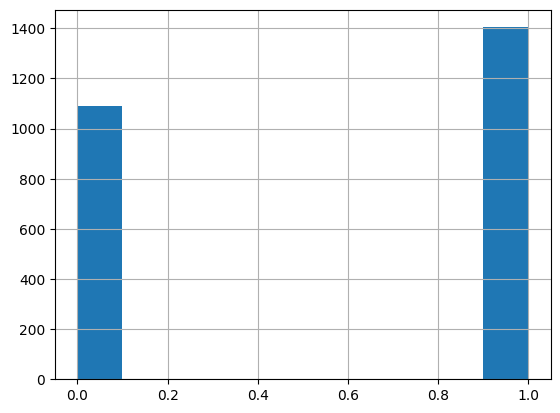

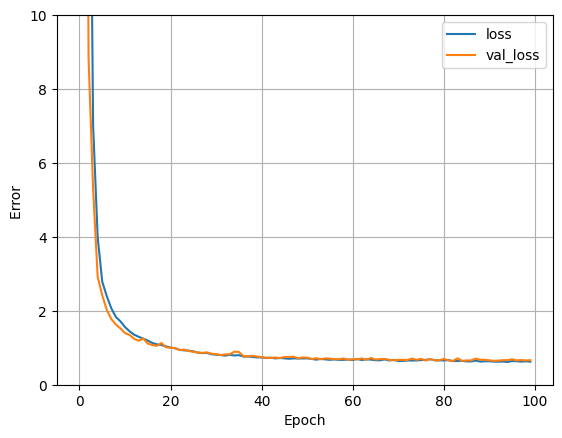

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss: 0.6456 - r2_score: 0.8632


[0.6456494331359863, 0.8632128834724426]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


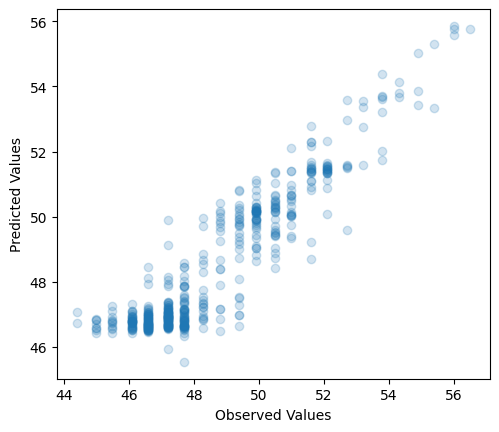

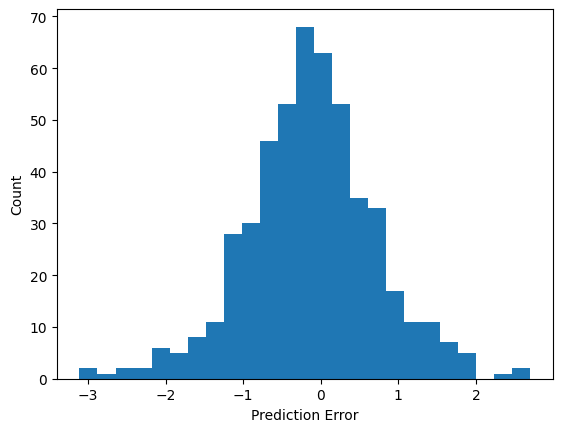

In [16]:
def plot_loss(history, ylim=10):
    plt.clf()
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0, ylim])
    plt.xlabel('Epoch')
    plt.ylabel('Error ')
    plt.legend()
    plt.grid(True)

def plot_scatter(x, y, x_label, y_label):
    plt.clf()
    plt.axes(aspect='equal')
    plt.scatter(x, y, alpha=0.2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

def plot_hist(data, x_label, y_label):
    plt.clf()
    plt.hist(data, bins=25)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show() 

# Convert fan speed into an on/off indicator.
df_data["fan_state"] = df_data.fan_speed.apply(lambda x: 1 if x > 0 else 0)
plt.clf()
df_data.fan_state.hist()
plt.show()

feature_cols = ["cpu_pct", "load_avg", "cpu_speed", "fan_speed"]

# Separate the feature data from the target data we want to predict.
X = df_data[feature_cols]
y = df_data.temp

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))
    
dnn_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

dnn_model.compile(loss='mean_absolute_error',
                  optimizer=tf.keras.optimizers.Adam(0.001),
                  metrics=[tf.keras.metrics.R2Score()]
)

history = dnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

plot_loss(history)
plt.show()

display(dnn_model.evaluate(X_test, y_test, verbose=1))

y_pred = dnn_model.predict(X_test).flatten()

plot_scatter(y_test, y_pred, 'Observed Values', 'Predicted Values')
plot_hist(y_pred-y_test, "Prediction Error", "Count")

# Tensorflow: Neural network classification

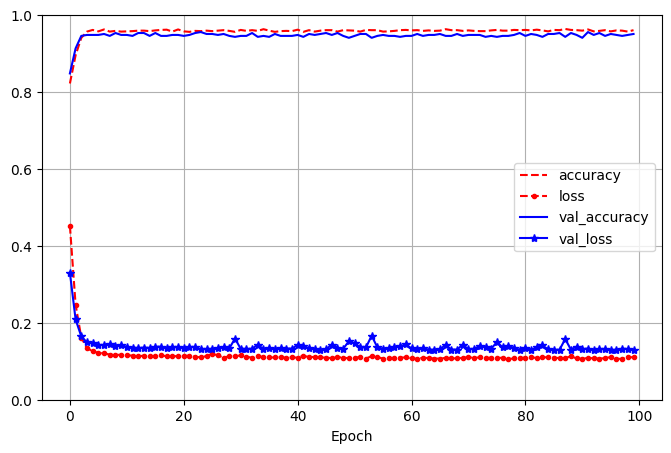

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.9640 - loss: 0.0985


[0.0985078290104866, 0.9639999866485596]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


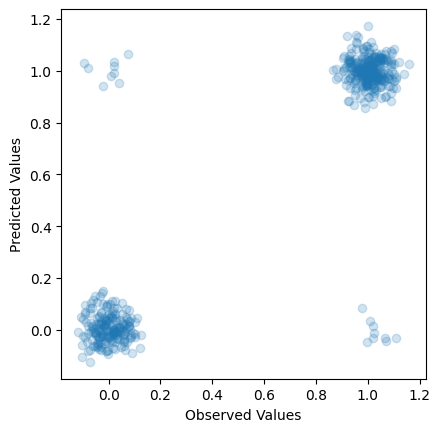

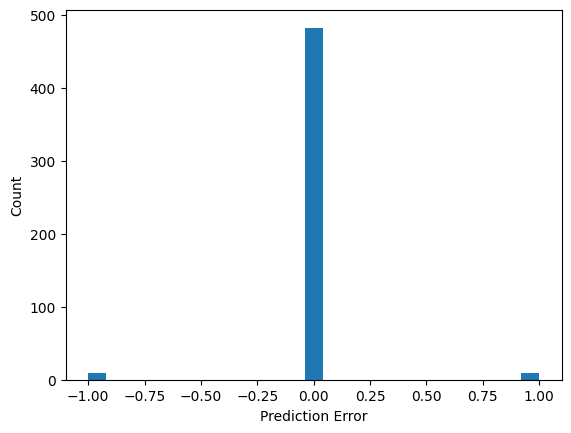

In [18]:
# see https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/ch10.html#id159
def rand_jitter(arr):
    stdev = .05 * (max(arr) - min(arr))
    return arr + np.random.randn(len(arr)) * stdev

feature_cols = ["load_avg", "temp"]
# feature_cols = ["cpu_pct", "load_avg", "cpu_speed", "temp"]
df_data["voltage_level"] = df_data.volts.apply(lambda x: 1 if x >= .825 else 0)

# Separate the feature data from the target data we want to predict.
X = df_data[feature_cols]
y = df_data.voltage_level

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))
    
dnn_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
    #tf.keras.layers.Dense(2, activation="softmax") # use this for "sparse labels"
])

# dnn_model.compile(loss='sparse_categorical_crossentropy', # use this for "sparse labels"
#                   optimizer="sgd",
#                   metrics=["accuracy"]
# )
dnn_model.compile(loss='binary_crossentropy',
                  optimizer="adam",
                  metrics=["accuracy"]
)

history = dnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

pd.DataFrame(history.history).plot(
    figsize=(8, 5), ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

display(dnn_model.evaluate(X_test, y_test, verbose=1))

y_proba = dnn_model.predict(X_test)
# y_pred = y_proba.argmax(axis=-1) # use this for "sparse labels"
y_pred = np.array([1 if x >= 0.5 else 0 for x in tf.squeeze(y_proba)])

plot_scatter(rand_jitter(y_test), rand_jitter(y_pred), 'Observed Values', 'Predicted Values')
plot_hist(y_pred-y_test, 'Prediction Error', 'Count')